<a href="https://colab.research.google.com/github/pranjaligupta0204/Image_generator/blob/main/Image_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Generator

In [ ]:
!pip install diffusers transformers accelerate torch torchvision
!pip install gradio
!pip install xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 11.3 MB/s eta 0:00:00


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import gradio as gr
from PIL import Image
import os
from datetime import datetime
import gc
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_model():
    model_id = "runwayml/stable-diffusion-v1-5"
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        use_safetensors=True
    )
    pipe = pipe.to("cuda")
    pipe.enable_xformers_memory_efficient_attention()
    return pipe

def generate_image(prompt, negative_prompt="", guidance_scale=7.5, num_steps=20):
    try:
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            guidance_scale=guidance_scale,
            num_inference_steps=num_steps,
            height=512,
            width=512
        ).images[0]

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"generated_image_{timestamp}.png"
        image.save(filename)

        with open("generation_log.txt", "a") as f:
            f.write(f"{timestamp}: {prompt}\n")

        gc.collect()
        torch.cuda.empty_cache()

        return image
    except Exception as e:
        logger.error(f"Generation failed: {str(e)}")
        return f"Error: {str(e)}"

def create_interface():
    with gr.Blocks(title="AI Image Generator") as interface:
        gr.Markdown("# 🎨 AI Image Generator")
        gr.Markdown("Enter a text description and get an AI-generated image!")

        with gr.Row():
            with gr.Column():
                prompt_input = gr.Textbox(
                    label="Image Description",
                    placeholder="A beautiful sunset over mountains...",
                    lines=3
                )
                negative_prompt = gr.Textbox(
                    label="What to avoid (optional)",
                    placeholder="blurry, low quality...",
                    lines=2
                )

                with gr.Row():
                    guidance = gr.Slider(1, 20, value=7.5, label="Creativity Level")
                    steps = gr.Slider(10, 50, value=20, label="Quality Steps")

                generate_btn = gr.Button("🎨 Generate Image", variant="primary")

            with gr.Column():
                output_image = gr.Image(label="Generated Image")

        generate_btn.click(
            fn=generate_image,
            inputs=[prompt_input, negative_prompt, guidance, steps],
            outputs=output_image
        )

        gr.Examples(
            examples=[
                ["A cute robot painting on canvas"],
                ["A magical forest with glowing mushrooms"],
                ["A cozy coffee shop in winter"],
                ["A futuristic city at night"],
                ["A cat wearing sunglasses"]
            ],
            inputs=[prompt_input]
        )

    return interface

pipe = load_model()
interface = create_interface()
interface.launch(share=True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

ModuleNotFoundError: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers

In [ ]:
def load_light_model():
    model_id = "CompVis/stable-diffusion-v1-4"
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True
    )
    pipe = pipe.to("cuda")
    return pipe

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import gradio as gr

# Check if GPU is available
if torch.cuda.is_available():
    device = "cuda"
    print("✅ GPU is available and ready to use")
else:
    device = "cpu"
    print("⚠️ No GPU found. It will be very slow on CPU")


✅ GPU is available and ready to use


In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to(device)

print("✅ Model loaded successfully!")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Model loaded successfully!


In [ ]:
import datetime

import gradio as gr
import datetime

def generate_images(prompt, num_images, steps, guidance):
    result = pipe(
        prompt,
        num_inference_steps=int(steps),
        guidance_scale=float(guidance),
        num_images_per_prompt=int(num_images)
    )
    images = result.images
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    for i, img in enumerate(images):
        filename = f"{save_path}/{timestamp}_img{i+1}.png"
        img.save(filename)

    return images


In [ ]:
with gr.Blocks() as demo:
    gr.Markdown("## 🎨 Text-to-Image with Stable Diffusion")

    prompt = gr.Textbox(label="Prompt", placeholder="A futuristic city at sunset")
    num_images = gr.Slider(1, 4, step=1, value=1, label="Number of Images")
    steps = gr.Slider(10, 50, step=5, value=30, label="Quality (Steps)")
    guidance = gr.Slider(5, 15, step=0.5, value=7.5, label="Creativity vs Accuracy")

    gallery = gr.Gallery(label="Generated Images", columns=2, height="auto")

    btn = gr.Button("🚀 Generate")

    btn.click(fn=generate_images,
              inputs=[prompt, num_images, steps, guidance],
              outputs=gallery)

In [ ]:
demo.launch(share=True)  # share=True gives you a public link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a03d3b1b7437ddf192.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/30 [00:00<?, ?it/s]

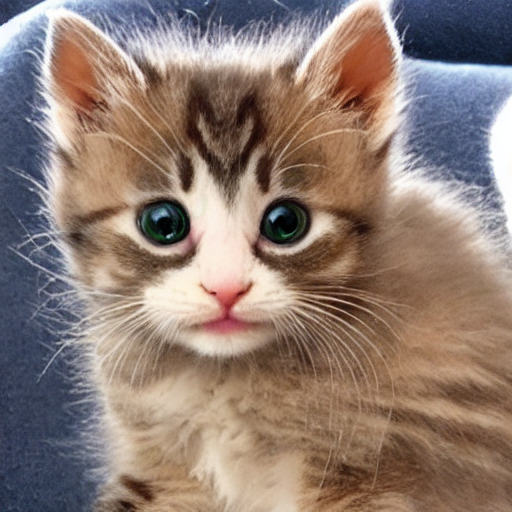

In [ ]:
image = pipe("kitten", num_inference_steps=30).images[0]
image.save("test.png")
image


# TRY#

In [ ]:
!pip install diffusers transformers accelerate torch torchvision
!pip install gradio

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import gradio as gr
from PIL import Image
import os
from datetime import datetime
import gc
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_model():
    model_id = "runwayml/stable-diffusion-v1-5"
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        use_safetensors=True
    )
    pipe = pipe.to("cuda")
    return pipe

def generate_image(prompt, negative_prompt="", guidance_scale=7.5, num_steps=20):
    try:
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            guidance_scale=guidance_scale,
            num_inference_steps=num_steps,
            height=512,
            width=512
        ).images[0]

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"generated_image_{timestamp}.png"
        image.save(filename)

        with open("generation_log.txt", "a") as f:
            f.write(f"{timestamp}: {prompt}\n")

        gc.collect()
        torch.cuda.empty_cache()

        return image
    except Exception as e:
        logger.error(f"Generation failed: {str(e)}")
        return f"Error: {str(e)}"

def create_interface():
    with gr.Blocks(title="AI Image Generator") as interface:
        gr.Markdown("# AI Image Generator")
        gr.Markdown("Enter a text description and get an AI-generated image!")

        with gr.Row():
            with gr.Column():
                prompt_input = gr.Textbox(
                    label="Image Description",
                    placeholder="A beautiful sunset over mountains...",
                    lines=3
                )
                negative_prompt = gr.Textbox(
                    label="What to avoid (optional)",
                    placeholder="blurry, low quality...",
                    lines=2
                )

                with gr.Row():
                    guidance = gr.Slider(1, 20, value=7.5, label="Creativity Level")
                    steps = gr.Slider(10, 50, value=20, label="Quality Steps")

                generate_btn = gr.Button(" Generate Image", variant="primary")

            with gr.Column():
                output_image = gr.Image(label="Generated Image")

        generate_btn.click(
            fn=generate_image,
            inputs=[prompt_input, negative_prompt, guidance, steps],
            outputs=output_image
        )

        gr.Examples(
            examples=[
                ["A cute robot painting on canvas"],
                ["A magical forest with glowing mushrooms"],
                ["A cozy coffee shop in winter"],
                ["A futuristic city at night"],
                ["A cat wearing sunglasses"]
            ],
            inputs=[prompt_input]
        )

    return interface

pipe = load_model()
interface = create_interface()
interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b18c8983767f8b6380.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def load_light_model():
    model_id = "CompVis/stable-diffusion-v1-4"
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True
    )
    pipe = pipe.to("cuda")
    return pipe

In [ ]:
import requests
import io

def generate_with_hf_api(prompt):
    API_URL = "https://api-inference.huggingface.co/models/runwayml/stable-diffusion-v1-5"

    def query(payload):
        response = requests.post(API_URL, json=payload)
        return response.content

    image_bytes = query({"inputs": prompt})
    image = Image.open(io.BytesIO(image_bytes))
    return image

def create_api_interface():
    with gr.Blocks(title="AI Image Generator - API Version") as interface:
        gr.Markdown("# AI Image Generator (HF API)")

        prompt_input = gr.Textbox(label="Image Description", lines=3)
        generate_btn = gr.Button("Generate Image")
        output_image = gr.Image(label="Generated Image")

        generate_btn.click(
            fn=generate_with_hf_api,
            inputs=prompt_input,
            outputs=output_image
        )

    return interface